## <b> Classification Project: Churn Prediction</b>

In [1]:
#library importation:

import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_auc_score

### <b>Data Preparation</b>

In [2]:
df = pd.read_csv('Customer-Churn_data.csv')
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


In [3]:
#transpose the columns a rows
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [4]:
#data types of the columns
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [6]:
#column normalization and strings column cleaning
df.columns = df.columns.str.lower().str.replace(' ', '_', regex=False)

strings_columns = list(df.dtypes[df.dtypes=='string'].index)

for col in strings_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_', regex=False)

In [7]:
#df.churn = (df.churn == 'yes').astype(int)
df.churn = (df.churn.str.lower() == 'yes').astype(int)

In [8]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


### <b>Setting up the validation framework</b>

In [9]:
#Data splitting & Target Extraction
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [10]:
df_train, df_val = train_test_split(df_train_full, test_size=0.25, random_state=42, stratify=df_train_full['churn'])

In [11]:
df_train_full = df_train_full.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [12]:
y_full_train = df_train_full.churn.values
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [13]:
print(f"Original dataset size: {len(df)}")
print(f"Training Full set size: {len(df_train_full)} ({len(df_train_full)/len(df)*100:.1f}%)")
print(f"Test set size: {len(df_test)} ({len(df_test)/len(df)*100:.1f}%)")
print(f"Training set size: {len(df_train)} ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validation set size: {len(df_val)} ({len(df_val)/len(df)*100:.1f}%)")

Original dataset size: 7043
Training Full set size: 5634 (80.0%)
Test set size: 1409 (20.0%)
Training set size: 4225 (60.0%)
Validation set size: 1409 (20.0%)


In [14]:
#del df_train_full['churn']
del df_train['churn']
del df_val['churn']
#del df_test['churn']

### <b>Exploratory Data Analysis</b>

In [15]:
df_train_full.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [16]:
df_train_full.churn.value_counts()

churn
0    4138
1    1496
Name: count, dtype: int64

In [17]:
df_train_full.churn.value_counts(normalize=True)

churn
0    0.734469
1    0.265531
Name: proportion, dtype: float64

In [18]:
global_mean = df_train_full.churn.mean()
round(global_mean, 7)

np.float64(0.2655307)

In [19]:
df_train_full.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

df_train_full.columns

In [20]:
numerical_vars = df.select_dtypes(include=['int64', 'float64'])
categorical_vars = df.select_dtypes(include=['str'])

print("Numerical Variables:")
print(numerical_vars.columns)

print("\nCategorical Variables:")
print(categorical_vars.columns)

Numerical Variables:
Index(['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges', 'churn'], dtype='str')

Categorical Variables:
Index(['customerid', 'gender', 'partner', 'dependents', 'phoneservice',
       'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
       'contract', 'paperlessbilling', 'paymentmethod'],
      dtype='str')


In [21]:
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
              'phoneservice', 'multiplelines', 'internetservice', 
              'onlinesecurity', 'onlinebackup', 'deviceprotection',
              'techsupport', 'streamingtv', 'streamingmovies',
              'contract', 'paperlessbilling', 'paymentmethod']
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [22]:
df_train_full[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

### <b>Feature Importance</b>

#### <b>Churn Rate</b>

In [23]:
female_mean = df_train_full[df_train_full.gender=='female'].churn.mean()
print('gender == female: ', round(female_mean, 3))

male_mean = df_train_full[df_train_full.gender == 'male'].churn.mean()
print('gender == male: ', round(male_mean, 3))

gender == female:  0.271
gender == male:  0.26


In [24]:
print("Global avrg churn:", round(global_mean,3))
print("Female avrg churn to Global avrg churn:", round(female_mean / global_mean,3))
print("Male avrg churn to Global avrg churn:", round(male_mean / global_mean,3))

Global avrg churn: 0.266
Female avrg churn to Global avrg churn: 1.02
Male avrg churn to Global avrg churn: 0.981


In [25]:
print(global_mean - female_mean)
print(global_mean - male_mean)

-0.005310210939122428
0.005052701575950558


In [26]:
partner_yes = df_train_full[df_train_full.partner == 'yes'].churn.mean()
print('partner == yes: ', round(partner_yes, 3))

partner_no = df_train_full[df_train_full.partner == 'no'].churn.mean()
print('partner == no: ', round(partner_no, 3))

partner == yes:  0.201
partner == no:  0.326


In [27]:
print("Global avrg churn:", round(global_mean,3))
print("Customers with partners avrg churn to Global avrg churn:", round(partner_yes / global_mean, 3))
print("Customers without partners avrg churn to Global avrg churn:", round(partner_no / global_mean,3))

Global avrg churn: 0.266
Customers with partners avrg churn to Global avrg churn: 0.756
Customers without partners avrg churn to Global avrg churn: 1.229


In [28]:
print(global_mean - partner_yes)
print(global_mean - partner_no)

0.06479810569267436
-0.06091557456646046


In [29]:
#Actual Churn Group
print("Global avrg churn:", round(global_mean,3))
print("Churn rate of customers with partners:", round(global_mean * (partner_yes / global_mean),3))
print("Churn rate of customers without partners:",round(global_mean * (partner_no / global_mean),3))

Global avrg churn: 0.266
Churn rate of customers with partners: 0.201
Churn rate of customers without partners: 0.326


#### <b>Risk Ratio</b>

In [30]:
df_group = df_train_full.groupby(by='gender').churn.agg(['mean'])
df_group['diff'] = df_group['mean'] - global_mean
df_group['risk'] = df_group['mean'] / global_mean
df_group

,mean,diff,risk
gender,,,
female,0.270841,0.005310,1.019998
male,0.260478,-0.005053,0.980971


In [31]:
from IPython.display import display

In [32]:
global_mean = df_train_full.churn.mean()
global_mean

np.float64(0.2655307064252751)

In [33]:
for col in categorical:
    df_group = ( 
        df_train_full
            .groupby(by=col)
            .churn
            .agg(['mean'])
    )
    df_group['diff'] = df_group['mean'] - global_mean
    df_group['risk'] = df_group['mean'] / global_mean
    display(df_group.sort_values('risk', ascending=False))

,mean,diff,risk
gender,,,
female,0.270841,0.005310,1.019998
male,0.260478,-0.005053,0.980971


,mean,diff,risk
seniorcitizen,,,
1,0.413907,0.148377,1.558793
0,0.237098,-0.028433,0.892922


,mean,diff,risk
partner,,,
no,0.326446,0.060916,1.229411
yes,0.200733,-0.064798,0.755968


,mean,diff,risk
dependents,,,
no,0.312326,0.046795,1.176233
yes,0.155674,-0.109856,0.586276


,mean,diff,risk
phoneservice,,,
yes,0.266824,0.001293,1.004871
no,0.253623,-0.011908,0.955156


,mean,diff,risk
multiplelines,,,
yes,0.284105,0.018574,1.069952
no_phone_service,0.253623,-0.011908,0.955156
no,0.251397,-0.014134,0.946771


,mean,diff,risk
internetservice,,,
fiber_optic,0.415558,0.150028,1.565010
dsl,0.191851,-0.073679,0.722521
no,0.076606,-0.188924,0.288502


,mean,diff,risk
onlinesecurity,,,
no,0.416014,0.150484,1.566727
yes,0.145342,-0.120189,0.547363
no_internet_service,0.076606,-0.188924,0.288502


,mean,diff,risk
onlinebackup,,,
no,0.398693,0.133162,1.501494
yes,0.216531,-0.048999,0.815467
no_internet_service,0.076606,-0.188924,0.288502


,mean,diff,risk
deviceprotection,,,
no,0.387706,0.122175,1.460117
yes,0.226825,-0.038705,0.854234
no_internet_service,0.076606,-0.188924,0.288502


,mean,diff,risk
techsupport,,,
no,0.413472,0.147941,1.557153
yes,0.152855,-0.112676,0.575657
no_internet_service,0.076606,-0.188924,0.288502


,mean,diff,risk
streamingtv,,,
no,0.335418,0.069887,1.263197
yes,0.298945,0.033415,1.125841
no_internet_service,0.076606,-0.188924,0.288502


,mean,diff,risk
streamingmovies,,,
no,0.333333,0.067803,1.255348
yes,0.301320,0.035789,1.134784
no_internet_service,0.076606,-0.188924,0.288502


,mean,diff,risk
contract,,,
month-to-month,0.426533,0.161002,1.606340
one_year,0.117987,-0.147544,0.444343
two_year,0.028379,-0.237151,0.106878


,mean,diff,risk
paperlessbilling,,,
yes,0.33594,0.070409,1.265164
no,0.16414,-0.101390,0.618159


,mean,diff,risk
paymentmethod,,,
electronic_check,0.449921,0.184390,1.694420
mailed_check,0.190328,-0.075203,0.716782
bank_transfer_(automatic),0.174475,-0.091056,0.657080
credit_card_(automatic),0.152404,-0.113126,0.573961


#### <b>Mutual Importance</b>

In [34]:
from sklearn.metrics import mutual_info_score

In [35]:
print(mutual_info_score(df_train_full.churn, df_train_full.contract))
print(mutual_info_score(df_train_full.churn, df_train_full.gender))

0.0966515250997
6.877785208564413e-05


In [36]:
def calculate_mi(series):
    return mutual_info_score(series, df_train_full.churn)

df_mi = df_train_full[categorical].apply(calculate_mi)

df_mi = (
    df_mi
        .sort_values(ascending=False)
        .to_frame(name='MI')
   
)

display(df_mi.head())
display(df_mi.tail())

,MI
contract,0.096652
onlinesecurity,0.063393
techsupport,0.060935
internetservice,0.053313
onlinebackup,0.045424


,MI
partner,0.010227
seniorcitizen,0.010059
multiplelines,0.000654
gender,0.000069
phoneservice,0.000040


#### <b>Correlation</b>

In [37]:
#direction
df_train_full[numerical].corrwith(df_train_full.churn).to_frame('correlation')

,correlation
tenure,-0.344925
monthlycharges,0.188574
totalcharges,-0.193370


In [38]:
#absolute impact
df_train_full[numerical].corrwith(df_train_full.churn).abs().to_frame('correlation')

,correlation
tenure,0.344925
monthlycharges,0.188574
totalcharges,0.193370


In [39]:
print(df_train_full[df_train_full.tenure <= 2].churn.mean())
print(df_train_full[df_train_full.tenure > 2].churn.mean())
print(df_train_full[(df_train_full.tenure > 2) & (df_train_full.tenure <= 12)].churn.mean())
print(df_train_full[df_train_full.tenure > 12].churn.mean())

0.5863636363636363
0.22295938882187374
0.4064814814814815
0.17205957883923986


In [40]:
print(df_train_full[df_train_full.monthlycharges <= 20].churn.mean())
print(df_train_full[(df_train_full.monthlycharges > 20) & (df_train_full.monthlycharges <=50)].churn.mean())
print(df_train_full[df_train_full.monthlycharges > 50].churn.mean())

0.0912621359223301
0.19062027231467474
0.3152488806952857


#### <b>One-hot encoding</b>

In [41]:
train_dict = df_train[categorical + numerical].to_dict(orient='records')

In [42]:
train_dict[0]

{'gender': 'male',
 'seniorcitizen': 1,
 'partner': 'no',
 'dependents': 'no',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'dsl',
 'onlinesecurity': 'yes',
 'onlinebackup': 'yes',
 'deviceprotection': 'no',
 'techsupport': 'yes',
 'streamingtv': 'no',
 'streamingmovies': 'no',
 'contract': 'two_year',
 'paperlessbilling': 'yes',
 'paymentmethod': 'bank_transfer_(automatic)',
 'tenure': 67,
 'monthlycharges': 64.55,
 'totalcharges': 4250.1}

In [43]:
dv = DictVectorizer(sparse=False)
dv.fit(train_dict)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [44]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [45]:
X_train = dv.transform(train_dict)

In [46]:
X_train.shape

(4225, 45)

In [47]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

### <b>Using Logistic Regression</b>

### <b>Training Logistic Regression</b>

In [48]:
model = LogisticRegression(solver='liblinear', random_state=1)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [49]:
model.predict_proba(X_train)

array([[0.98842828, 0.01157172],
       [0.93815058, 0.06184942],
       [0.5043365 , 0.4956635 ],
       ...,
       [0.98811357, 0.01188643],
       [0.98465289, 0.01534711],
       [0.91867753, 0.08132247]], shape=(4225, 2))

In [50]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [51]:
model.predict_proba(X_val)

array([[0.47025033, 0.52974967],
       [0.87903876, 0.12096124],
       [0.90232672, 0.09767328],
       ...,
       [0.99066368, 0.00933632],
       [0.40560644, 0.59439356],
       [0.63855222, 0.36144778]], shape=(1409, 2))

In [52]:
y_pred = model.predict_proba(X_val)[:, 1]

In [53]:
y_pred

array([0.52974967, 0.12096124, 0.09767328, ..., 0.00933632, 0.59439356,
       0.36144778], shape=(1409,))

In [54]:
churn_decision = y_pred >= 0.5
churn_decision

array([ True, False, False, ..., False,  True, False], shape=(1409,))

In [55]:
(y_val == churn_decision).mean()

np.float64(0.8275372604684174)

In [56]:
df_val[churn_decision]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
0,0988-jrwwp,female,0,no,no,3,yes,no,dsl,no,no,no,no,yes,no,month-to-month,yes,electronic_check,54.20,140.40
12,2460-ngxbj,male,1,yes,yes,11,yes,yes,fiber_optic,no,no,no,no,no,no,month-to-month,yes,credit_card_(automatic),75.20,775.30
20,6088-bxmrg,female,0,yes,yes,32,yes,yes,fiber_optic,no,yes,no,no,yes,yes,month-to-month,yes,electronic_check,98.85,3089.60
23,5052-pnlos,male,0,no,no,3,yes,yes,fiber_optic,no,yes,yes,no,yes,yes,month-to-month,yes,bank_transfer_(automatic),105.35,323.25
28,9801-gdwgv,female,0,no,no,39,yes,yes,fiber_optic,no,yes,yes,no,yes,yes,month-to-month,yes,electronic_check,103.45,3994.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1393,2038-oeqzh,male,0,no,no,4,yes,no,fiber_optic,no,no,yes,no,no,yes,month-to-month,no,electronic_check,86.05,308.10
1394,6298-qdfnh,male,0,no,no,22,yes,yes,fiber_optic,no,yes,no,no,no,no,month-to-month,yes,electronic_check,79.35,1730.35
1398,2575-gfsoe,female,0,yes,yes,7,yes,no,fiber_optic,no,no,no,no,no,no,month-to-month,yes,electronic_check,69.00,506.90
1403,1084-uqchv,male,0,no,yes,1,yes,no,fiber_optic,no,no,no,no,no,no,month-to-month,no,bank_transfer_(automatic),69.75,69.75


In [57]:
df_val[churn_decision].customerid

0       0988-jrwwp
12      2460-ngxbj
20      6088-bxmrg
23      5052-pnlos
28      9801-gdwgv
           ...    
1393    2038-oeqzh
1394    6298-qdfnh
1398    2575-gfsoe
1403    1084-uqchv
1407    0939-yapaf
Name: customerid, Length: 303, dtype: str

#### <b>Apply Model to the Validation Dataset</b>

#### <b> Calculate the Model Accuracy </b>

In [58]:
y_val

array([0, 0, 0, ..., 0, 1, 0], shape=(1409,))

In [59]:
len(y_val)

1409

In [60]:
churn_decision.astype(int)

array([1, 0, 0, ..., 0, 1, 0], shape=(1409,))

In [61]:
(y_val == churn_decision).mean()

np.float64(0.8275372604684174)

* An accuracy of <b>82.7%</b> on the <b>validation data</b>

In [62]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val
df_pred['correct'] = df_pred.prediction == df_pred.actual
df_pred

,probability,prediction,actual,correct
0,0.529750,1,0,False
1,0.120961,0,0,True
2,0.097673,0,0,True
3,0.003967,0,0,True
4,0.227947,0,0,True
...,...,...,...,...
1404,0.420216,0,0,True
1405,0.096986,0,0,True
1406,0.009336,0,0,True
1407,0.594394,1,1,True


In [63]:
df_pred.correct.mean()

np.float64(0.8275372604684174)

* The model has an 82.7% model accuracy. 

### <b>Model Interpretation</b>

In [64]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [65]:
model.intercept_[0]

np.float64(-0.12388329575463121)

In [66]:
model.coef_[0].round(3)

array([ 0.57 , -0.114, -0.58 , -0.017, -0.107,  0.071, -0.102, -0.093,
       -0.045, -0.079, -0.399,  0.377, -0.102,  0.   , -0.194,  0.144,
       -0.074,  0.124, -0.102, -0.147,  0.198, -0.102, -0.22 , -0.225,
        0.101, -0.095, -0.029, -0.041, -0.09 ,  0.183, -0.176,  0.144,
       -0.268,  0.124, -0.122, -0.102,  0.1  , -0.073, -0.102,  0.051,
        0.185, -0.102, -0.207, -0.053,  0.   ])

In [67]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.57),
 'contract=one_year': np.float64(-0.114),
 'contract=two_year': np.float64(-0.58),
 'dependents=no': np.float64(-0.017),
 'dependents=yes': np.float64(-0.107),
 'deviceprotection=no': np.float64(0.071),
 'deviceprotection=no_internet_service': np.float64(-0.102),
 'deviceprotection=yes': np.float64(-0.093),
 'gender=female': np.float64(-0.045),
 'gender=male': np.float64(-0.079),
 'internetservice=dsl': np.float64(-0.399),
 'internetservice=fiber_optic': np.float64(0.377),
 'internetservice=no': np.float64(-0.102),
 'monthlycharges': np.float64(0.0),
 'multiplelines=no': np.float64(-0.194),
 'multiplelines=no_phone_service': np.float64(0.144),
 'multiplelines=yes': np.float64(-0.074),
 'onlinebackup=no': np.float64(0.124),
 'onlinebackup=no_internet_service': np.float64(-0.102),
 'onlinebackup=yes': np.float64(-0.147),
 'onlinesecurity=no': np.float64(0.198),
 'onlinesecurity=no_internet_service': np.float64(-0.102),
 'onlinesecurity=yes': 

#### <b>Training a Smaller Model with Fewer Features </b>

In [68]:
small = ['contract', 'tenure', 'monthlycharges']

In [69]:
df_train[small].iloc[:10]

,contract,tenure,monthlycharges
0,two_year,67,64.55
1,two_year,72,116.45
2,month-to-month,15,89.00
3,month-to-month,16,100.70
4,month-to-month,9,95.50
5,month-to-month,43,49.05
6,month-to-month,17,94.20
7,month-to-month,16,49.95
8,two_year,66,61.15
9,one_year,67,105.40


In [70]:
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'two_year', 'tenure': 67, 'monthlycharges': 64.55},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 116.45},
 {'contract': 'month-to-month', 'tenure': 15, 'monthlycharges': 89.0},
 {'contract': 'month-to-month', 'tenure': 16, 'monthlycharges': 100.7},
 {'contract': 'month-to-month', 'tenure': 9, 'monthlycharges': 95.5},
 {'contract': 'month-to-month', 'tenure': 43, 'monthlycharges': 49.05},
 {'contract': 'month-to-month', 'tenure': 17, 'monthlycharges': 94.2},
 {'contract': 'month-to-month', 'tenure': 16, 'monthlycharges': 49.95},
 {'contract': 'two_year', 'tenure': 66, 'monthlycharges': 61.15},
 {'contract': 'one_year', 'tenure': 67, 'monthlycharges': 105.4}]

In [71]:
dicts_train_small = df_train[small].to_dict(orient='records')

In [72]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [73]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [74]:
X_train_small = dv_small.transform(dicts_train_small)
model_small = LogisticRegression(solver='liblinear', random_state=1)
model_small.fit(X_train_small, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [75]:
model_small.intercept_[0]

np.float64(-1.7810639795623362)

In [76]:
dict(zip(dv_small.get_feature_names_out(), model_small.coef_.round(3)))

{'contract=month-to-month': array([ 0.363, -0.633, -1.511,  0.025, -0.032])}

In [77]:
dicts_val_small = df_val[small].to_dict(orient='records')
X_small_val = dv_small.transform(dicts_val_small)

y_pred_small = model_small.predict_proba(X_small_val)[:, 1]

### <b> Using the Model </b>

In [78]:
df_train_full

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,4223-bkeor,female,0,no,yes,21,yes,no,dsl,yes,...,yes,no,no,yes,one_year,no,mailed_check,64.85,1336.80,0
1,6035-riiom,female,0,no,no,54,yes,yes,fiber_optic,no,...,no,no,yes,yes,two_year,yes,bank_transfer_(automatic),97.20,5129.45,0
2,3797-vtidr,male,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,23.45,23.45,1
3,2568-brgyx,male,0,no,no,4,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.20,237.95,1
4,2775-sefee,male,0,no,yes,0,yes,yes,dsl,yes,...,no,yes,no,no,two_year,yes,bank_transfer_(automatic),61.90,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0684-aosih,male,0,yes,no,1,yes,no,fiber_optic,yes,...,no,no,yes,yes,month-to-month,yes,electronic_check,95.00,95.00,1
5630,5982-psmkw,female,0,yes,yes,23,yes,yes,dsl,yes,...,yes,yes,yes,yes,two_year,yes,credit_card_(automatic),91.10,2198.30,0
5631,8044-bgwpi,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,month-to-month,yes,electronic_check,21.15,306.05,0
5632,7450-nwrtr,male,1,no,no,12,yes,yes,fiber_optic,no,...,yes,no,yes,yes,month-to-month,yes,electronic_check,99.45,1200.15,1


In [79]:
#getting the dictionaries
dicts_full_train = df_train_full[categorical + numerical].to_dict(orient='records')
dicts_full_train[:3]

[{'gender': 'female',
  'seniorcitizen': 0,
  'partner': 'no',
  'dependents': 'yes',
  'phoneservice': 'yes',
  'multiplelines': 'no',
  'internetservice': 'dsl',
  'onlinesecurity': 'yes',
  'onlinebackup': 'no',
  'deviceprotection': 'yes',
  'techsupport': 'no',
  'streamingtv': 'no',
  'streamingmovies': 'yes',
  'contract': 'one_year',
  'paperlessbilling': 'no',
  'paymentmethod': 'mailed_check',
  'tenure': 21,
  'monthlycharges': 64.85,
  'totalcharges': 1336.8},
 {'gender': 'female',
  'seniorcitizen': 0,
  'partner': 'no',
  'dependents': 'no',
  'phoneservice': 'yes',
  'multiplelines': 'yes',
  'internetservice': 'fiber_optic',
  'onlinesecurity': 'no',
  'onlinebackup': 'yes',
  'deviceprotection': 'no',
  'techsupport': 'no',
  'streamingtv': 'yes',
  'streamingmovies': 'yes',
  'contract': 'two_year',
  'paperlessbilling': 'yes',
  'paymentmethod': 'bank_transfer_(automatic)',
  'tenure': 54,
  'monthlycharges': 97.2,
  'totalcharges': 5129.45},
 {'gender': 'male',
  's

In [80]:
#creating a DictVectorizer
dv = DictVectorizer(sparse=False)

In [81]:
X_full_train = dv.fit_transform(dicts_full_train)

In [82]:
#training the the model on this feature matrix
y_full_train = df_train_full.churn.values
model = LogisticRegression(solver='liblinear')
model.fit(X_full_train, y_full_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [83]:
# on test data
dicts_test = df_test[categorical + numerical].to_dict(orient='records')
X_test = dv.transform(dicts_test)

In [84]:
# on predictions
y_pred = model.predict_proba(X_test)[:, 1]

In [85]:
#computing accuracy
churn_decision = (y_pred >= 0.5)
(churn_decision == y_test).mean()

np.float64(0.8168914123491838)

* An accuracy of <b>81.6%</b> on the <b>test data</b> is slightly more accurate than what we had in the validation data.
* Minor differences in performance are acceptable, but significant differences between training and validation/test data can indeed indicate potential issues with the model, such as overfitting.
* Ensuring that the model’s performance is consistent across different datasets is an important aspect of model evaluation and generalization.

In [86]:
# a customer sample on our test data
customer = dicts_test[10]
customer

{'gender': 'male',
 'seniorcitizen': 0,
 'partner': 'no',
 'dependents': 'no',
 'phoneservice': 'yes',
 'multiplelines': 'no',
 'internetservice': 'no',
 'onlinesecurity': 'no_internet_service',
 'onlinebackup': 'no_internet_service',
 'deviceprotection': 'no_internet_service',
 'techsupport': 'no_internet_service',
 'streamingtv': 'no_internet_service',
 'streamingmovies': 'no_internet_service',
 'contract': 'month-to-month',
 'paperlessbilling': 'no',
 'paymentmethod': 'mailed_check',
 'tenure': 1,
 'monthlycharges': 20.45,
 'totalcharges': 20.45}

In [87]:
# to get feature matrix on the requested customer as a dictionay
X_small = dv.transform([customer])
X_small

array([[ 1.  ,  0.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  ,  0.  ,  0.  ,
         1.  ,  0.  ,  0.  ,  1.  , 20.45,  1.  ,  0.  ,  0.  ,  0.  ,
         1.  ,  0.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ,
         0.  ,  0.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  ,
         0.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  ,  0.  ,  1.  , 20.45]])

In [88]:
X_small.shape
print('One Customer with 45 features:',X_small.shape)

One Customer with 45 features: (1, 45)


In [89]:
model.predict_proba(X_small)[0, 1]

np.float64(0.19273423358159034)

* This customer has a probability of only <b>19%</b> of churning.
* We assume this customer is not going to churn.

In [90]:
# lets check the actual value
y_test[10]

np.int64(0)

* A decision not sending an email to this customer was correct.

In [91]:
#testing another sample of customer
customer = dicts_test[-1]
X_small = dv.transform([customer])
model.predict_proba(X_small)[0,1]

np.float64(0.5130739204341468)

* We see this customer has a probability of about 51% of churning.
* We assume this customer is going to churn.

In [92]:
# Lets check the actual value
y_test[-1]

np.int64(1)

* The prediction is correct.

### <b>Evaluation Metrics for Classification</b>

#### <b>Accuracy and Dummy Model</b>

In [93]:
y_pred = model.predict_proba(X_val)[:, 1]
churn = y_pred >= 0.5
(churn == y_val).mean()

np.float64(0.830376153300213)

In [94]:
from sklearn.metrics import accuracy_score

In [95]:
accuracy_score(y_val, y_pred >= 0.5)

0.830376153300213

#### <b>Evaluate the model on different thresholds </b>

In [96]:
thresholds = np.linspace(0, 1, 11)
thresholds

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [97]:
scores = []

for threshold in thresholds:
    churn_decision = (y_pred >=threshold)
    score = (y_val == churn_decision).mean()
    print('%.1f %.3f' % (threshold, score))
    scores.append(score)

0.0 0.265
0.1 0.602
0.2 0.709
0.3 0.786
0.4 0.815
0.5 0.830
0.6 0.822
0.7 0.786
0.8 0.740
0.9 0.735
1.0 0.735


In [98]:
#using the built-in fxn

scores = []

for threshold in thresholds:
    score = accuracy_score(y_val, y_pred >= threshold)
    print('%.1f %.3f' % (threshold, score))
    scores.append(score)

0.0 0.265
0.1 0.602
0.2 0.709
0.3 0.786
0.4 0.815
0.5 0.830
0.6 0.822
0.7 0.786
0.8 0.740
0.9 0.735
1.0 0.735


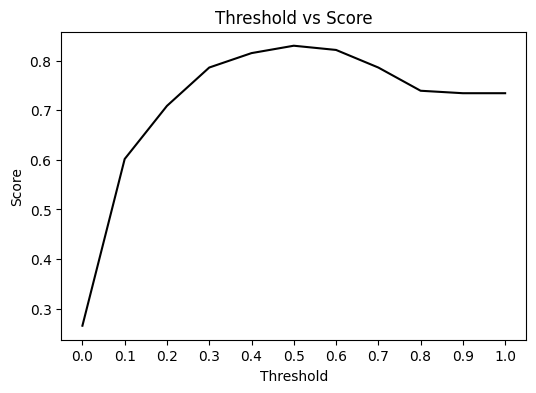

In [99]:
plt.figure(figsize=(6, 4))

plt.plot(thresholds, scores, color='black')

plt.title('Threshold vs Score')
plt.xlabel('Threshold')
plt.ylabel('Score')

plt.xticks(np.linspace(0, 1, 11))

# plt.savefig('04_threshold_accuracy.svg')

plt.show()

In [100]:
churn_small = y_pred_small >= 0.5
(churn_small == y_val).mean()

np.float64(0.7977288857345636)

In [101]:
accuracy_score(y_val, churn_small)

0.7977288857345636

In [102]:
size_val = len(y_val)
baseline = np.repeat(False, size_val)
baseline

array([False, False, False, ..., False, False, False], shape=(1409,))

In [103]:
accuracy_score(baseline, y_val)

0.7345635202271115

In [104]:
from collections import Counter

In [105]:
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [106]:
Counter(y_val)

Counter({np.int64(0): 1035, np.int64(1): 374})

In [107]:
print(1035/1409)

0.7345635202271115


In [108]:
y_val.mean()

np.float64(0.2654364797728886)

In [109]:
1 - y_val.mean()

np.float64(0.7345635202271115)

### <b>Confusion Table </b>

In [110]:
#people who are going to churn
actual_positive = (y_val == 1)
#people who are not going to churn
actual_negative = (y_val == 0)

In [111]:
threshold = 0.5
predict_positive = (y_pred >= threshold)
predict_negative = (y_pred < threshold)

In [112]:
predict_positive & actual_positive

array([False, False, False, ..., False,  True, False], shape=(1409,))

In [113]:
tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()
fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

In [114]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

In [115]:
confusion_matrix

array([[953,  82],
       [157, 217]])

In [116]:
(confusion_matrix / confusion_matrix.sum()).round(3)

array([[0.676, 0.058],
       [0.111, 0.154]])

In [117]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
accuracy

np.float64(0.830376153300213)

#### <b>Precision & Recall </b>

In [118]:
precision = tp / (tp + fp)
precision

np.float64(0.725752508361204)

In [119]:
# promotional email goes to 299 people, but 217 are actually going to churn while 82 will not (--> 27% are mistakes)
tp + fp

np.int64(299)

In [120]:
recall = tp / (tp + fn)
recall

np.float64(0.5802139037433155)

In [121]:
# For 42% of people who are churning we failed to identify them
tp + fn

np.int64(374)

#### <b>ROC Curve (Receiver Operating Characteristics)</b>

In [122]:
# tpr = recall
tpr = tp / (tp + fn)
tpr

np.float64(0.5802139037433155)

In [123]:
fpr = fp / (fp + tn)
fpr

np.float64(0.07922705314009662)

In [124]:
scores = []
thresholds = np.linspace(0, 1, 101)
 
for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
 
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)
 
    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
 
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
 
    scores.append((t, tp, tn, fp, fn))
 
scores

[(np.float64(0.0), np.int64(374), np.int64(0), np.int64(1035), np.int64(0)),
 (np.float64(0.01), np.int64(374), np.int64(111), np.int64(924), np.int64(0)),
 (np.float64(0.02), np.int64(372), np.int64(204), np.int64(831), np.int64(2)),
 (np.float64(0.03), np.int64(372), np.int64(259), np.int64(776), np.int64(2)),
 (np.float64(0.04), np.int64(370), np.int64(300), np.int64(735), np.int64(4)),
 (np.float64(0.05), np.int64(367), np.int64(338), np.int64(697), np.int64(7)),
 (np.float64(0.06), np.int64(364), np.int64(377), np.int64(658), np.int64(10)),
 (np.float64(0.07), np.int64(362), np.int64(411), np.int64(624), np.int64(12)),
 (np.float64(0.08), np.int64(362), np.int64(436), np.int64(599), np.int64(12)),
 (np.float64(0.09), np.int64(359), np.int64(456), np.int64(579), np.int64(15)),
 (np.float64(0.1), np.int64(357), np.int64(491), np.int64(544), np.int64(17)),
 (np.float64(0.11), np.int64(356), np.int64(511), np.int64(524), np.int64(18)),
 (np.float64(0.12), np.int64(355), np.int64(532),

In [125]:
columns = ['threshold','tp','tn','fp','fn']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores

,threshold,tp,tn,fp,fn
0,0.00,374,0,1035,0
1,0.01,374,111,924,0
2,0.02,372,204,831,2
3,0.03,372,259,776,2
4,0.04,370,300,735,4
...,...,...,...,...,...
96,0.96,0,1035,0,374
97,0.97,0,1035,0,374
98,0.98,0,1035,0,374
99,0.99,0,1035,0,374


In [126]:
df_scores[::10]

,threshold,tp,tn,fp,fn
0,0.0,374,0,1035,0
10,0.1,357,491,544,17
20,0.2,330,669,366,44
30,0.3,296,812,223,78
40,0.4,260,889,146,114
50,0.5,217,953,82,157
60,0.6,167,991,44,207
70,0.7,89,1019,16,285
80,0.8,7,1035,0,367
90,0.9,0,1035,0,374


In [127]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
df_scores[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.0,374,0,1035,0,1.000000,1.000000
10,0.1,357,491,544,17,0.954545,0.525604
20,0.2,330,669,366,44,0.882353,0.353623
30,0.3,296,812,223,78,0.791444,0.215459
40,0.4,260,889,146,114,0.695187,0.141063
50,0.5,217,953,82,157,0.580214,0.079227
60,0.6,167,991,44,207,0.446524,0.042512
70,0.7,89,1019,16,285,0.237968,0.015459
80,0.8,7,1035,0,367,0.018717,0.000000
90,0.9,0,1035,0,374,0.000000,0.000000


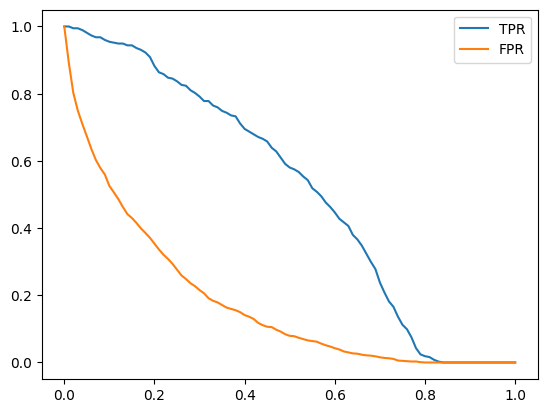

In [128]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')
plt.legend()

#### <b>Random Model</b>

In [129]:
np.random.seed()
y_rand = np.random.uniform(0, 1, size=len(y_val))
y_rand.round(3)

array([0.65 , 0.762, 0.15 , ..., 0.718, 0.314, 0.457], shape=(1409,))

In [130]:
#Accuracy for our random model
((y_rand >= 0.5) == y_val).mean()

np.float64(0.5145493257629524)

In [131]:
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []
    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t) 

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, tn, fp, fn))

    columns = ['threshold', 'tp', 'tn', 'fp','fn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

    return df_scores

In [132]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)
df_rand[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.0,374,0,1035,0,1.000000,1.000000
10,0.1,327,116,919,47,0.874332,0.887923
20,0.2,289,226,809,85,0.772727,0.781643
30,0.3,249,328,707,125,0.665775,0.683092
40,0.4,209,435,600,165,0.558824,0.579710
50,0.5,187,538,497,187,0.500000,0.480193
60,0.6,157,660,375,217,0.419786,0.362319
70,0.7,118,760,275,256,0.315508,0.265700
80,0.8,83,845,190,291,0.221925,0.183575
90,0.9,44,933,102,330,0.117647,0.098551


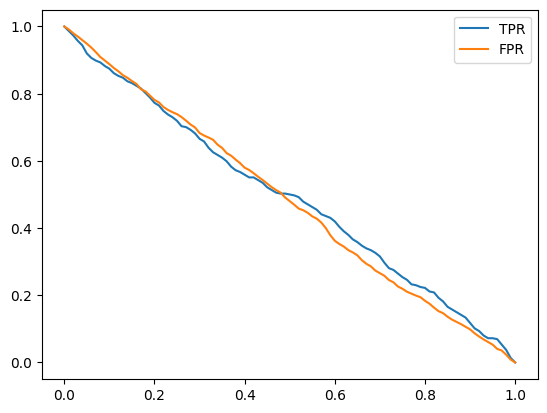

In [133]:
plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR')
plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR')
plt.legend()

#### <b> Ideal Model </b>

In [134]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()
num_neg, num_pos

(np.int64(1035), np.int64(374))

In [135]:
y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [136]:
y_ideal_pred = np.linspace(0, 1, len(y_ideal))
y_ideal_pred

array([0.00000000e+00, 7.10227273e-04, 1.42045455e-03, ...,
       9.98579545e-01, 9.99289773e-01, 1.00000000e+00], shape=(1409,))

In [137]:
1 - y_val.mean()

np.float64(0.7345635202271115)

In [138]:
accuracy_ideal = ((y_ideal_pred >= 0.734) == y_ideal).mean()
accuracy_ideal

np.float64(0.9992902767920511)

In [139]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.0,374,0,1035,0,1.000000,1.000000
10,0.1,374,141,894,0,1.000000,0.863768
20,0.2,374,282,753,0,1.000000,0.727536
30,0.3,374,423,612,0,1.000000,0.591304
40,0.4,374,564,471,0,1.000000,0.455072
50,0.5,374,704,331,0,1.000000,0.319807
60,0.6,374,845,190,0,1.000000,0.183575
70,0.7,374,986,49,0,1.000000,0.047343
80,0.8,282,1035,0,92,0.754011,0.000000
90,0.9,141,1035,0,233,0.377005,0.000000


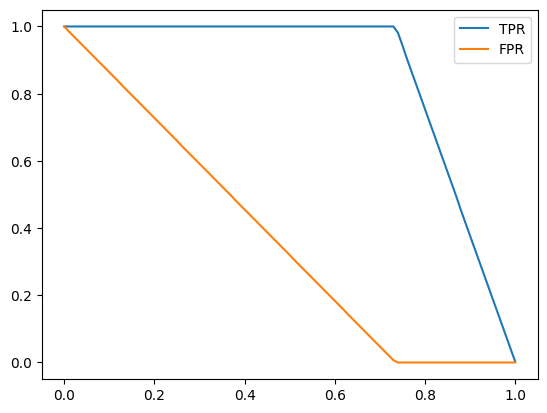

In [140]:
plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR')
plt.legend()

#### <b> Putting it all together </b>

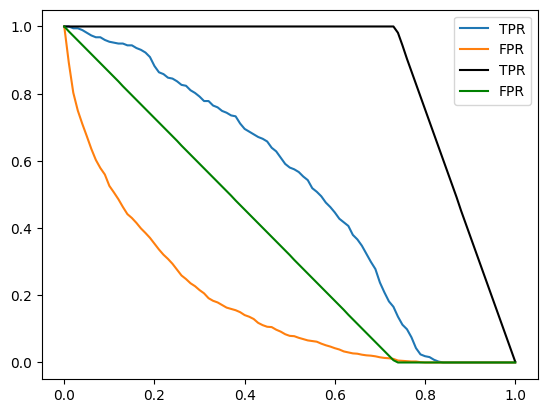

In [141]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')

#plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR')
#plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR')

plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR', color='black')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR', color='green')

plt.legend()

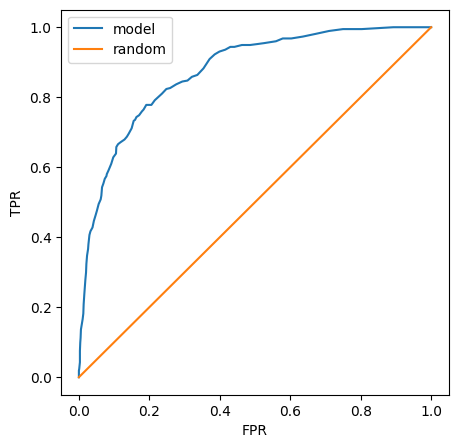

In [142]:
plt.figure(figsize=(5,5))

plt.plot(df_scores.fpr, df_scores.tpr, label='model')
plt.plot([0,1], [0,1], label='random')

#plt.plot(df_rand.fpr, df_rand.tpr, label='random')
#plt.plot(df_ideal.fpr, df_ideal.tpr, label='ideal')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

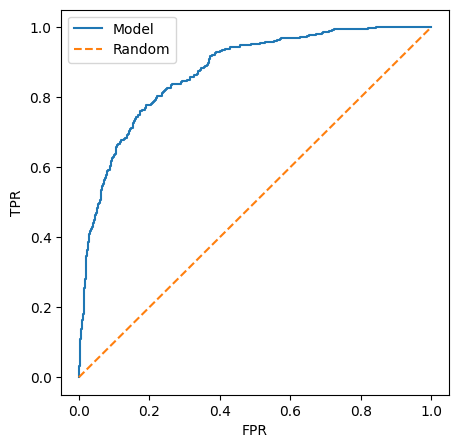

In [143]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

plt.figure(figsize=(5,5))

plt.plot(fpr, tpr, label='Model')
plt.plot([0,1], [0,1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

#### <b> ROC AUC - Area under the ROC curve </b>

In [144]:
from sklearn.metrics import auc
auc(fpr, tpr)

0.8726420212353715

In [145]:
auc(df_scores.fpr, df_scores.tpr)

0.872463768115942

In [146]:
auc(df_ideal.fpr, df_ideal.tpr)

0.9999367072257097

In [147]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
auc(fpr, tpr)

0.8726420212353715

In [148]:
roc_auc_score(y_val, y_pred)

0.8726420212353715

* AUC tells us the probability that a randomly selected positive example has a score that is higher than a randomly selected negative example.

In [149]:
neg = y_pred[y_val == 0]
pos = y_pred[y_val == 1]

In [150]:
import random
pos_ind = random.randint(0, len(pos) -1)
neg_ind = random.randint(0, len(neg) -1)

In [151]:
pos[pos_ind] > neg[neg_ind]

np.True_

In [152]:
n = 100000
success = 0

for i in range(n):
    pos_ind = random.randint(0, len(pos) -1)
    neg_ind = random.randint(0, len(neg) -1)

    if pos[pos_ind] > neg[neg_ind]:
        success +=1

success / n

0.87244

In [153]:
n = 50000

np.random.seed(1)
pos_ind = np.random.randint(0, len(pos), size=n)
neg_ind = np.random.randint(0, len(neg), size=n)
pos[pos_ind] > neg[neg_ind]

array([ True,  True,  True, ...,  True, False,  True], shape=(50000,))

In [154]:
(pos[pos_ind] > neg[neg_ind]).mean()

np.float64(0.87262)

### <b>Cross-Validation: Evaluating the same model on different subsets of data</b>

In [155]:
#K-Fold Cross-Validation
def train(df_train, y_train):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear')
    model.fit(X_train, y_train)

    return dv, model

In [156]:
dv, model = train(df_train, y_train)

In [157]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.fit_transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [158]:
y_pred = predict(df_val, dv, model)
y_pred

array([0.52974967, 0.12096124, 0.09767328, ..., 0.00933632, 0.59439356,
       0.36144778], shape=(1409,))

In [159]:
from sklearn.model_selection import KFold

In [160]:
kfold = KFold(n_splits = 10, shuffle=True, random_state=1)

In [161]:
kfold.split(df_train_full)

<generator object _BaseKFold.split at 0x1171e3640>

In [162]:
train_idx, val_idx = next(kfold.split(df_train_full))
len(train_idx), len(val_idx)

(5070, 564)

In [163]:
len(df_train_full)

5634

In [164]:
df_train = df_train_full.iloc[train_idx]
df_val = df_train_full.iloc[val_idx]

In [165]:
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
scores = []

for train_idx, val_idx in kfold.split(df_train_full):
    df_train = df_train_full.iloc[train_idx]
    df_val = df_train_full.iloc[val_idx]

    y_train = df_train.churn.values
    y_val = df_val.churn.values

    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

scores

[0.8097769214158763,
 0.8577332597207983,
 0.8361996779388083,
 0.8551546630088005,
 0.8564179878740719,
 0.8197427738000531,
 0.855044390637611,
 0.839363875109425,
 0.8478233478233479,
 0.8223836025519208]

In [166]:
!pip3 install tqdm
from tqdm.auto import tqdm

kfold = KFold(n_splits=10, shuffle=True, random_state=1)
scores = []

for train_idx, val_idx in tqdm(kfold.split(df_train_full)):
    df_train = df_train_full.iloc[train_idx]
    df_val = df_train_full.iloc[val_idx]

    y_train = df_train.churn.values
    y_val = df_val.churn.values

    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

scores

/Users/mac/Desktop/ml_projects/classification/customer_churn/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
10it [00:00, 11.52it/s]


[0.8097769214158763,
 0.8577332597207983,
 0.8361996779388083,
 0.8551546630088005,
 0.8564179878740719,
 0.8197427738000531,
 0.855044390637611,
 0.839363875109425,
 0.8478233478233479,
 0.8223836025519208]

#### <b>Getting the average prediction and the spread within predictions </b>

We can utilize the scores generated to compute the average score across the 10 folds, which is 84.1%, with a standard deviation of 0.012.

In [167]:
print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.840 +- 0.017


#### <b> Parameter Tuning </b>

In [168]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C,solver='saga', max_iter=3000)
    model.fit(X_train, y_train)

    return dv, model

In [169]:
dv, model = train(df_train, y_train, C=0.001)

In [170]:
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

for C in [0.01, 0.1, 0.5, 1]:

    scores = []

    for train_idx, val_idx in kfold.split(df_train_full):
        df_train = df_train_full.iloc[train_idx]
        df_val = df_train_full.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

        #np.array(scores).round(3)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

C=0.01 0.797 +- 0.018
C=0.1 0.797 +- 0.018
C=0.5 0.797 +- 0.018
C=1 0.797 +- 0.018


- Implementing the same procedure using the ‘tqdm’ package, which provides a more visually appealing output.

In [171]:
n_splits = 10

for C in tqdm([0.01, 0.1, 0.5, 1]):
    scores = []

    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    for train_idx, val_idx in kfold.split(df_train_full):
        df_train = df_train_full.iloc[train_idx]
        df_val = df_train_full.iloc[val_idx]
        
        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

        print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|                                                                                                                    | 0/4 [00:00<?, ?it/s]

C=0.01 0.780 +- 0.000
C=0.01 0.794 +- 0.014
C=0.01 0.789 +- 0.014
C=0.01 0.792 +- 0.013
C=0.01 0.798 +- 0.017
C=0.01 0.797 +- 0.016
C=0.01 0.801 +- 0.017
C=0.01 0.798 +- 0.017
C=0.01 0.800 +- 0.017


 25%|███████████████████████████                                                                                 | 1/4 [00:19<00:59, 19.87s/it]

C=0.01 0.797 +- 0.018
C=0.1 0.780 +- 0.000
C=0.1 0.794 +- 0.014
C=0.1 0.789 +- 0.014
C=0.1 0.792 +- 0.013
C=0.1 0.798 +- 0.017
C=0.1 0.797 +- 0.016
C=0.1 0.801 +- 0.017
C=0.1 0.798 +- 0.017
C=0.1 0.800 +- 0.017


 50%|██████████████████████████████████████████████████████                                                      | 2/4 [00:39<00:39, 20.00s/it]

C=0.1 0.797 +- 0.018
C=0.5 0.780 +- 0.000
C=0.5 0.794 +- 0.014
C=0.5 0.789 +- 0.014
C=0.5 0.792 +- 0.013
C=0.5 0.798 +- 0.017
C=0.5 0.797 +- 0.016
C=0.5 0.801 +- 0.017
C=0.5 0.798 +- 0.017
C=0.5 0.800 +- 0.017


 75%|█████████████████████████████████████████████████████████████████████████████████                           | 3/4 [00:59<00:19, 19.95s/it]

C=0.5 0.797 +- 0.018
C=1 0.780 +- 0.000
C=1 0.794 +- 0.014
C=1 0.789 +- 0.014
C=1 0.792 +- 0.013
C=1 0.798 +- 0.017
C=1 0.797 +- 0.016
C=1 0.801 +- 0.017
C=1 0.798 +- 0.017
C=1 0.800 +- 0.017


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [01:19<00:00, 19.94s/it]

C=1 0.797 +- 0.018


- Training the final model using the entire training dataset (df_full_train) and then validate it using the test dataset.

In [172]:
dv, model = train(df_train_full, df_train_full.churn.values, C=1.0)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc

0.8236062086598279

### <b>Saving the Model</b>

In [173]:
import pickle

In [174]:
output_file = f'model_C={C}.bin'
output_file 

'model_C=1.bin'

In [175]:
f_out = open(output_file, 'wb')

In [176]:
pickle.dump((dv, model), f_out)

In [177]:
f_out.close()

In [178]:
#automatic closing of file
with open(output_file, 'wb') as f_out:
    pickle.dump((dv, model), f_out)

In [179]:
### <b>Loading the Model with Pickle</b>

In [180]:
import pickle

In [181]:
model_file = 'model_C=1.bin'

In [182]:
with open(model_file, 'rb') as f_in:
    dv, model = pickle.load(f_in)

In [183]:
dv, model

(DictVectorizer(sparse=False),
 LogisticRegression(max_iter=3000, solver='saga'))

In [184]:
#scoring a sample customer 

customer = {
    'gender': 'female',
    'seniorcitizen': 0,
    'partner': 'yes',
    'dependents': 'no',
    'phoneservice': 'no',
    'multiplelines': 'no_phone_service',
    'internetservice': 'dsl',
    'onlinesecurity': 'no',
    'onlinebackup': 'yes',
    'deviceprotection': 'no',
    'techsupport': 'no',
    'streamingtv': 'no',
    'streamingmovies': 'no',
    'contract': 'month-to-month',
    'paperlessbilling': 'yes',
    'paymentmethod': 'electronic_check',
    'tenure': 1,
    'monthlycharges': 29.85,
    'totalcharges': 29.85
}

In [185]:
X = dv.transform([customer])
X

array([[ 1.  ,  0.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  ,
         0.  ,  1.  ,  0.  ,  0.  , 29.85,  0.  ,  1.  ,  0.  ,  0.  ,
         0.  ,  1.  ,  1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  ,  1.  ,
         0.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  ,  0.  ,
         0.  ,  1.  ,  0.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  , 29.85]])

In [186]:
model.predict_proba(X)

array([[0.46122696, 0.53877304]])

In [187]:
model.predict_proba(X)[0,1]

np.float64(0.5387730361772198)

### <b> Turning Notebook into a Python Script </b>